In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix ,classification_report
from sklearn.preprocessing import LabelEncoder
from sklearn import tree
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import   KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split 
from sklearn.naive_bayes import BernoulliNB
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from joblib import dump



In [8]:
df = pd.read_csv("preprocessed_global_air_pollution_dataset.csv")

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23035 entries, 0 to 23034
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Country             23035 non-null  object
 1   AQI Value           23035 non-null  int64 
 2   AQI Category        23035 non-null  object
 3   CO AQI Value        23035 non-null  int64 
 4   CO AQI Category     23035 non-null  object
 5   Ozone AQI Value     23035 non-null  int64 
 6   Ozone AQI Category  23035 non-null  object
 7   NO2 AQI Value       23035 non-null  int64 
 8   NO2 AQI Category    23035 non-null  object
 9   PM2.5 AQI Value     23035 non-null  int64 
 10  PM2.5 AQI Category  23035 non-null  object
dtypes: int64(5), object(6)
memory usage: 1.9+ MB


In [10]:
df.shape

(23035, 11)

## Feature Extraction

In [11]:
# Create a new column 'Max_Pollutant' that contains the maximum AQI value among the pollutants for each row
df['Max_Pollutant'] = df[['CO AQI Value','Ozone AQI Value','NO2 AQI Value','PM2.5 AQI Value']].max(axis=1)

In [12]:
# Create a new column 'High_Pollutant_Count' that counts how many pollutants are in the 'Unhealthy', 'Very Unhealthy', or 'Hazardous' categories for each row
df['High_Pollutant_Count'] = (
    (df['CO AQI Category'].isin(['Unhealthy','Very Unhealthy','Hazardous'])).astype(int) +
    (df['Ozone AQI Category'].isin(['Unhealthy','Very Unhealthy','Hazardous'])).astype(int) +
    (df['NO2 AQI Category'].isin(['Unhealthy','Very Unhealthy','Hazardous'])).astype(int) +
    (df['PM2.5 AQI Category'].isin(['Unhealthy','Very Unhealthy','Hazardous'])).astype(int)
)

In [13]:
df.columns

Index(['Country', 'AQI Value', 'AQI Category', 'CO AQI Value',
       'CO AQI Category', 'Ozone AQI Value', 'Ozone AQI Category',
       'NO2 AQI Value', 'NO2 AQI Category', 'PM2.5 AQI Value',
       'PM2.5 AQI Category', 'Max_Pollutant', 'High_Pollutant_Count'],
      dtype='object')

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23035 entries, 0 to 23034
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Country               23035 non-null  object
 1   AQI Value             23035 non-null  int64 
 2   AQI Category          23035 non-null  object
 3   CO AQI Value          23035 non-null  int64 
 4   CO AQI Category       23035 non-null  object
 5   Ozone AQI Value       23035 non-null  int64 
 6   Ozone AQI Category    23035 non-null  object
 7   NO2 AQI Value         23035 non-null  int64 
 8   NO2 AQI Category      23035 non-null  object
 9   PM2.5 AQI Value       23035 non-null  int64 
 10  PM2.5 AQI Category    23035 non-null  object
 11  Max_Pollutant         23035 non-null  int64 
 12  High_Pollutant_Count  23035 non-null  int64 
dtypes: int64(7), object(6)
memory usage: 2.3+ MB


## Split Data

In [15]:
X = df.drop(columns=["AQI Category"]) 
y = df['AQI Category']

In [16]:
X_train, X_test, y_train , y_test = train_test_split(X , y , test_size=0.2 , random_state=42 , stratify= y)

In [17]:
X_train.shape , y_train.shape , X_test.shape , y_test.shape

((18428, 12), (18428,), (4607, 12), (4607,))

## Features Transformation

In [18]:
# Identify numeric columns
numerical_cols = X.select_dtypes(include=["float64", "int64"]).columns.to_list()
category_cols = X.select_dtypes(include=["object"]).columns.to_list()

In [19]:
#Create a pipeline for numerical features
num_pipeline = Pipeline(steps=[
     ('imputer', SimpleImputer(strategy='median')),
   ( "scalar",StandardScaler())])

cata_pipeline = Pipeline(steps= [ ('imputer', SimpleImputer(strategy='most_frequent'))
                                 , ('onehot', OneHotEncoder(handle_unknown='ignore'))])

In [20]:
# Combine numerical and categorical pipelines using ColumnTransformer

transformations = ColumnTransformer (
    transformers =[
        ("num_pipeline",num_pipeline,numerical_cols ),
        ("cata_pipeline",cata_pipeline,category_cols)
    ]

)

In [21]:
# Transform the train data
X_train_processed = transformations.fit_transform(X_train)

In [22]:
X_test_processed = transformations.transform(X_test)

In [23]:
X_train_processed.shape , X_test_processed.shape

((18428, 195), (4607, 195))

In [24]:
dump(transformations, "../src/artifacts/transformations.pkl")

['../src/artifacts/transformations.pkl']

## label encodeing target

In [25]:
target_encoder = LabelEncoder()
y_train_encoded = target_encoder.fit_transform(y_train)
y_test_encoded = target_encoder.transform(y_test)




In [26]:
y_train_encoded.shape , y_test_encoded.shape

((18428,), (4607,))

In [27]:
y_train_encoded

array([4, 0, 2, ..., 0, 0, 2])

In [28]:
target_encoder.classes_

array(['Good', 'Hazardous', 'Moderate', 'Unhealthy',
       'Unhealthy for Sensitive Groups', 'Very Unhealthy'], dtype=object)

In [29]:
dump(target_encoder, "../src/artifacts/target_encoder.pkl")

['../src/artifacts/target_encoder.pkl']

## model

In [30]:
def evaluate_classification_model(x_test_scaled, y_true, predictor, y_pred=None):
    # Handle KNN with batch prediction to avoid memory errors
    if y_pred is None:
        if isinstance(predictor, KNeighborsClassifier):
            batch_size = 100  # Small batch size for memory efficiency
            y_pred_batches = []
            for i in range(0, x_test_scaled.shape[0], batch_size):
                batch = x_test_scaled[i:i+batch_size]
                y_pred_batches.append(predictor.predict(batch))
            y_pred = np.concatenate(y_pred_batches)
        else:
            y_pred = predictor.predict(x_test_scaled)

    # Compute Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)

    # Compute Classification Report (includes Precision, Recall, F1-Score, Support)
    cr = classification_report(y_true, y_pred)

    # Compute Accuracy Score
    accuracy = accuracy_score(y_true, y_pred)

    print("="*30)
    print("Evaluation Metrics:")
    print("\nConfusion Matrix:")
    print(cm)

    # Visualize the confusion matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=target_encoder.classes_, yticklabels=target_encoder.classes_)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")
    plt.show()

    print("\nClassification Report:")
    print(cr)
    print(f"\nAccuracy: {accuracy:.4f}")
    print("="*30)

## logistic Regression

In [31]:
LR = LogisticRegression(random_state=42)
LR.fit(X_train_processed , y_train_encoded)

LogisticRegression(random_state=42)

Evaluation Metrics:

Confusion Matrix:
[[1938    0    0    0    0    0]
 [   0   36    0    0    0    2]
 [   0    0 1817    0    0    0]
 [   0    0    0  443    0    0]
 [   0    0    0    0  314    0]
 [   0    0    0    0    0   57]]


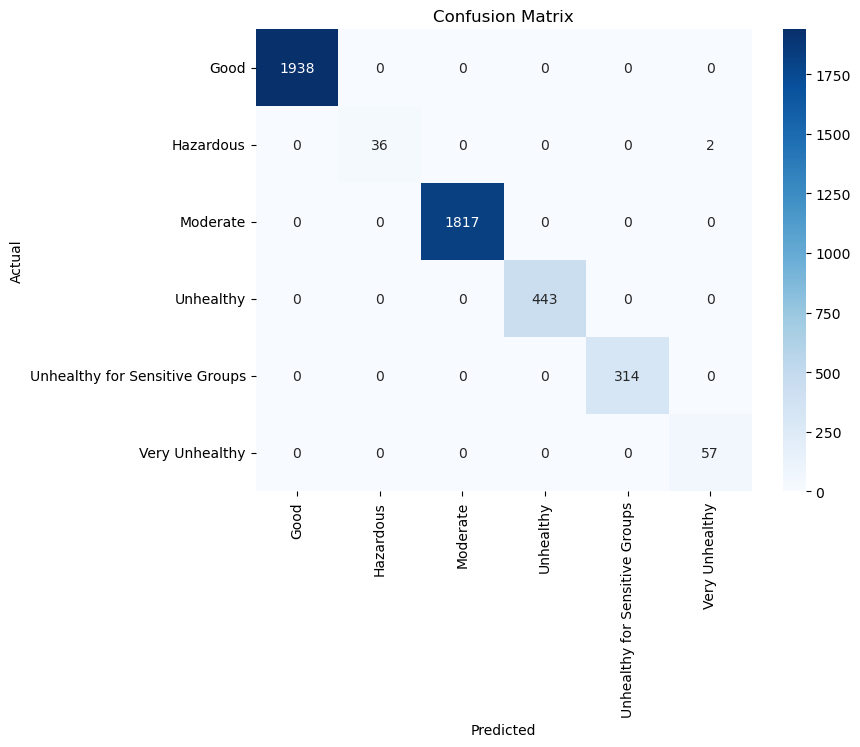


Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1938
           1       1.00      0.95      0.97        38
           2       1.00      1.00      1.00      1817
           3       1.00      1.00      1.00       443
           4       1.00      1.00      1.00       314
           5       0.97      1.00      0.98        57

    accuracy                           1.00      4607
   macro avg       0.99      0.99      0.99      4607
weighted avg       1.00      1.00      1.00      4607


Accuracy: 0.9996


In [32]:
evaluate_classification_model(X_test_processed ,y_test_encoded , LR)

## BernoulliNB

In [33]:
Berrnou = BernoulliNB()
Berrnou.fit(X_train_processed, y_train_encoded)

BernoulliNB()

Evaluation Metrics:

Confusion Matrix:
[[1938    0    0    0    0    0]
 [   0   36    0    0    0    2]
 [   0    0 1817    0    0    0]
 [   0    0    0  443    0    0]
 [   0    0    1    0  313    0]
 [   0    0    0    2    0   55]]


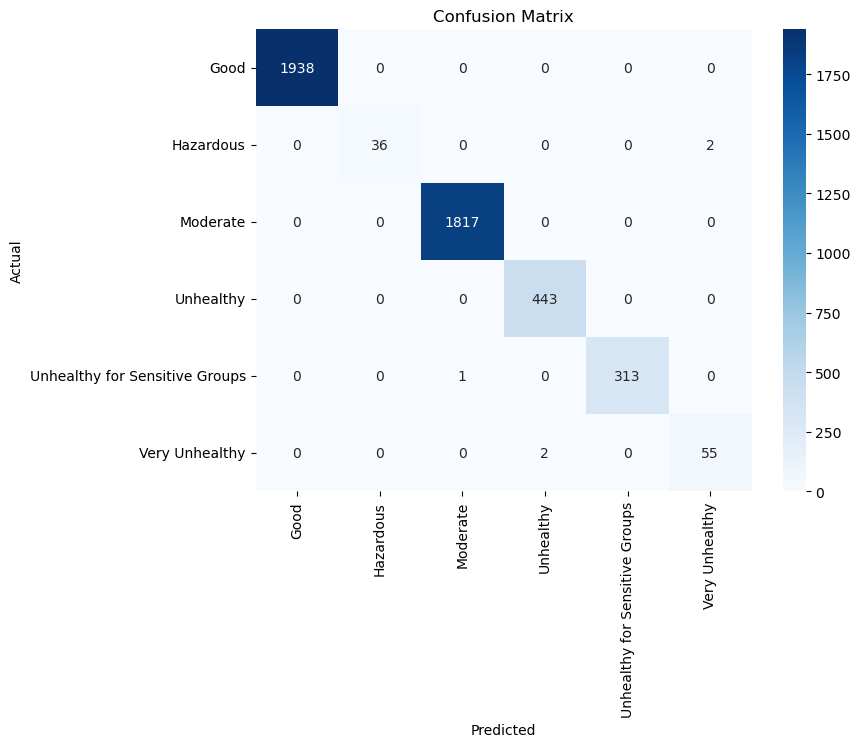


Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1938
           1       1.00      0.95      0.97        38
           2       1.00      1.00      1.00      1817
           3       1.00      1.00      1.00       443
           4       1.00      1.00      1.00       314
           5       0.96      0.96      0.96        57

    accuracy                           1.00      4607
   macro avg       0.99      0.98      0.99      4607
weighted avg       1.00      1.00      1.00      4607


Accuracy: 0.9989


In [34]:
evaluate_classification_model(X_test_processed ,y_test_encoded , Berrnou)

## KNN

In [35]:
KNN_Classifier = KNeighborsClassifier(n_neighbors=7, p=1, algorithm='auto')
KNN_Classifier.fit(X_train_processed, y_train_encoded)

KNeighborsClassifier(n_neighbors=7, p=1)

the Result in training data


c:\Users\Admin\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\Admin\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\Users\Admin\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Admin\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^

Evaluation Metrics:

Confusion Matrix:
[[1938    0    0    0    0    0]
 [   0   35    0    0    0    3]
 [   0    0 1817    0    0    0]
 [   0    0    0  443    0    0]
 [   0    0    0    0  314    0]
 [   0    1    0    1    0   55]]


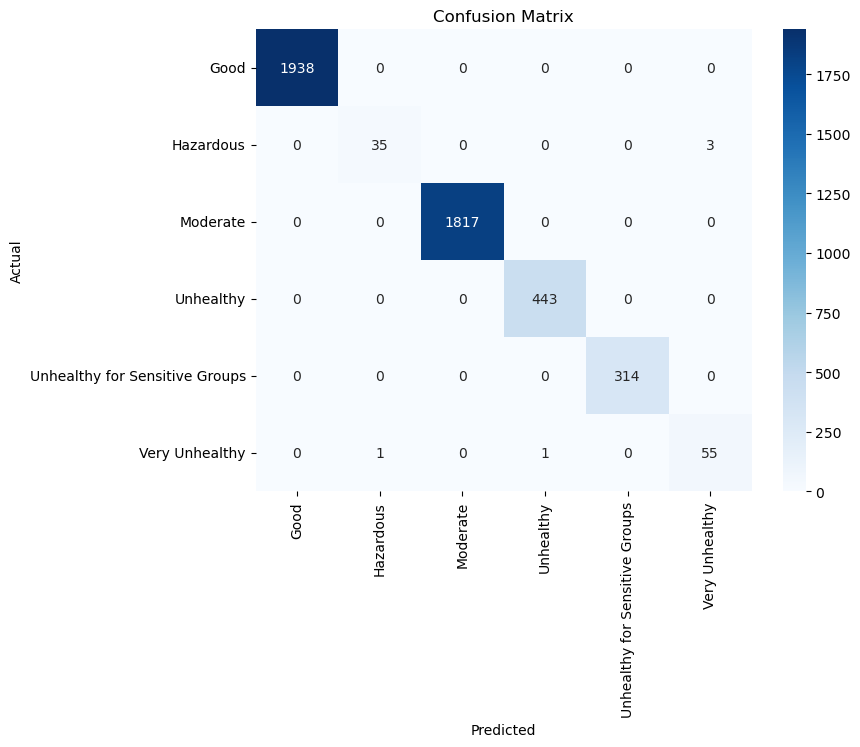


Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1938
           1       0.97      0.92      0.95        38
           2       1.00      1.00      1.00      1817
           3       1.00      1.00      1.00       443
           4       1.00      1.00      1.00       314
           5       0.95      0.96      0.96        57

    accuracy                           1.00      4607
   macro avg       0.99      0.98      0.98      4607
weighted avg       1.00      1.00      1.00      4607


Accuracy: 0.9989


In [36]:
print("the Result in training data")
evaluate_classification_model(X_test_processed, y_test_encoded, KNN_Classifier)

## Decision Tree

In [37]:
DTC = DecisionTreeClassifier(random_state=42)

## 

In [38]:
DTC.fit(X_train_processed, y_train_encoded)

DecisionTreeClassifier(random_state=42)

Evaluation Metrics:

Confusion Matrix:
[[1938    0    0    0    0    0]
 [   0   38    0    0    0    0]
 [   0    0 1817    0    0    0]
 [   0    0    0  443    0    0]
 [   0    0    0    0  314    0]
 [   0    0    0    0    0   57]]


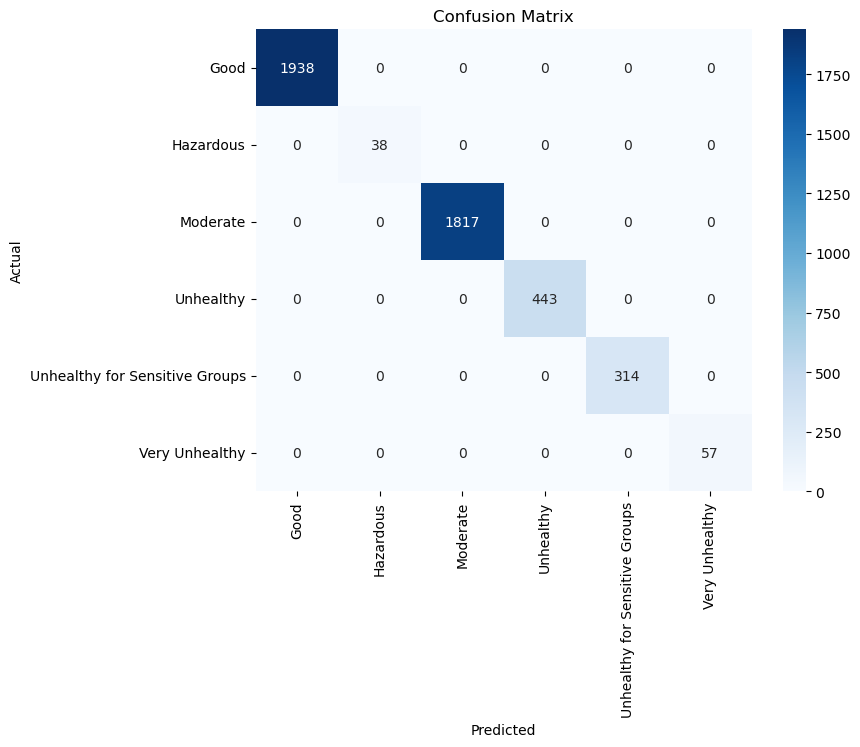


Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1938
           1       1.00      1.00      1.00        38
           2       1.00      1.00      1.00      1817
           3       1.00      1.00      1.00       443
           4       1.00      1.00      1.00       314
           5       1.00      1.00      1.00        57

    accuracy                           1.00      4607
   macro avg       1.00      1.00      1.00      4607
weighted avg       1.00      1.00      1.00      4607


Accuracy: 1.0000


In [39]:
evaluate_classification_model(X_test_processed ,y_test_encoded , DTC)

# Random Forest

In [40]:
random_forest = RandomForestClassifier(random_state=42)


In [41]:
random_forest.fit(X_train_processed, y_train_encoded)

RandomForestClassifier(random_state=42)

Evaluation Metrics:

Confusion Matrix:
[[1938    0    0    0    0    0]
 [   0   36    0    0    0    2]
 [   0    0 1817    0    0    0]
 [   0    0    0  443    0    0]
 [   0    0    0    0  314    0]
 [   0    1    0    0    0   56]]


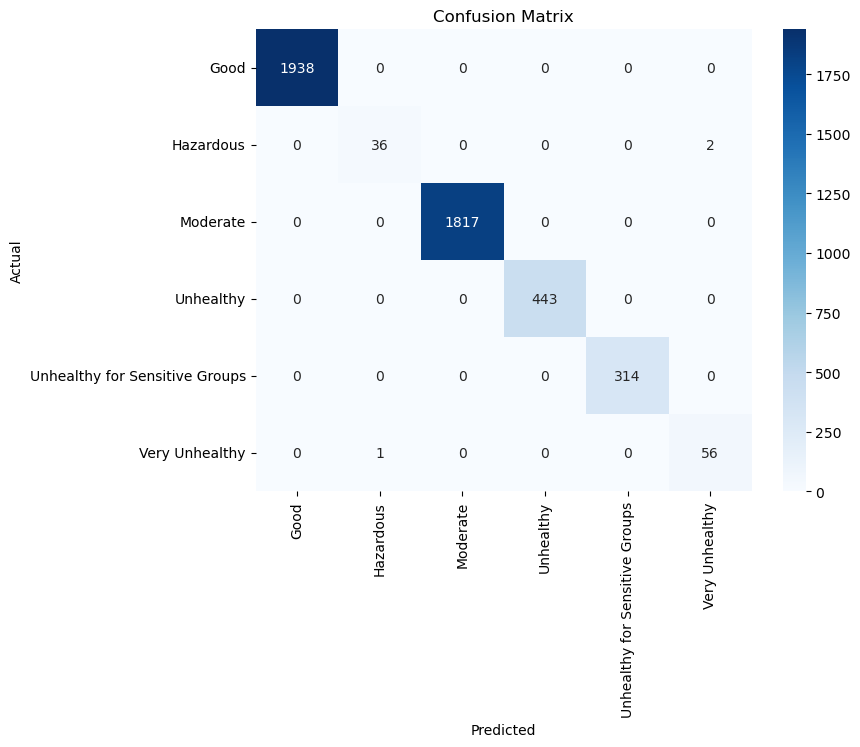


Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1938
           1       0.97      0.95      0.96        38
           2       1.00      1.00      1.00      1817
           3       1.00      1.00      1.00       443
           4       1.00      1.00      1.00       314
           5       0.97      0.98      0.97        57

    accuracy                           1.00      4607
   macro avg       0.99      0.99      0.99      4607
weighted avg       1.00      1.00      1.00      4607


Accuracy: 0.9993


In [42]:
evaluate_classification_model(X_test_processed ,y_test_encoded , random_forest)

# Support Vector Machine (SVM)

In [43]:
from sklearn import svm 


In [44]:
svm_classifier = svm.SVC(kernel='linear', random_state=42)


In [45]:
svm_classifier.fit(X_train_processed, y_train_encoded)

SVC(kernel='linear', random_state=42)

Evaluation Metrics:

Confusion Matrix:
[[1938    0    0    0    0    0]
 [   0   36    0    0    0    2]
 [   0    0 1817    0    0    0]
 [   0    0    0  443    0    0]
 [   0    0    0    0  314    0]
 [   0    0    0    0    0   57]]


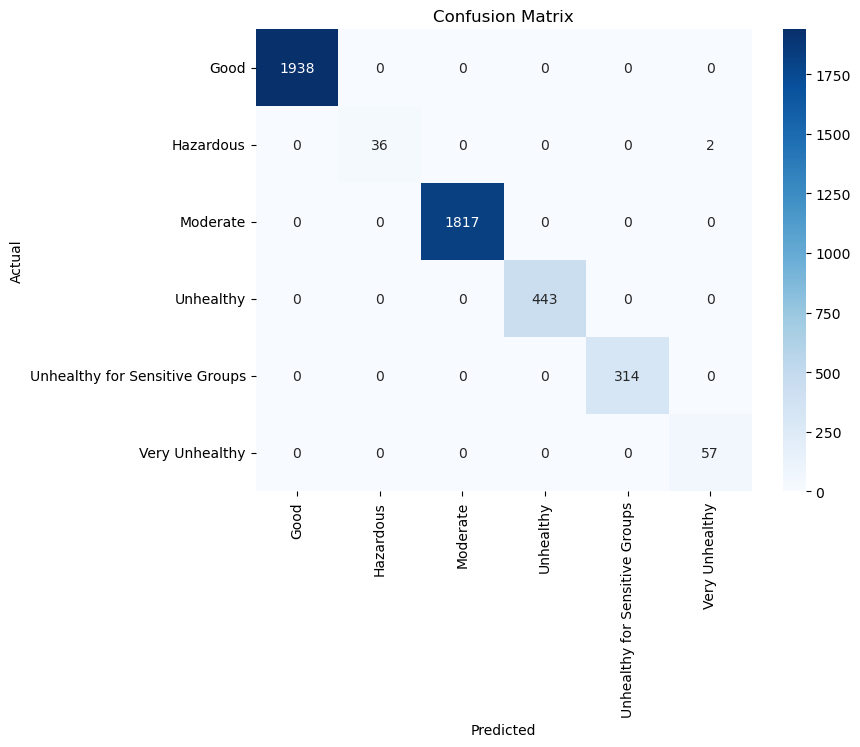


Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1938
           1       1.00      0.95      0.97        38
           2       1.00      1.00      1.00      1817
           3       1.00      1.00      1.00       443
           4       1.00      1.00      1.00       314
           5       0.97      1.00      0.98        57

    accuracy                           1.00      4607
   macro avg       0.99      0.99      0.99      4607
weighted avg       1.00      1.00      1.00      4607


Accuracy: 0.9996


In [46]:
evaluate_classification_model(X_test_processed ,y_test_encoded , svm_classifier)

## BEST MODEL

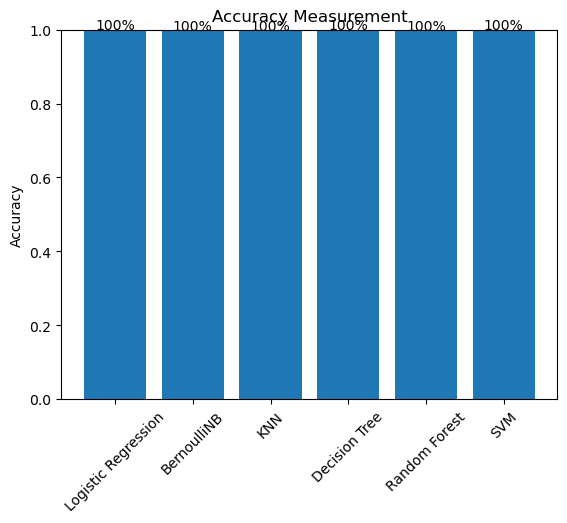

In [47]:
import matplotlib.pyplot as plt

models = [
    "Logistic Regression",
    "BernoulliNB",
    "KNN",
    "Decision Tree",
    "Random Forest",
    "SVM"
]
accuracies = [
    accuracy_score(y_test_encoded, LR.predict(X_test_processed)),
    accuracy_score(y_test_encoded, Berrnou.predict(X_test_processed)),
    accuracy_score(y_test_encoded, KNN_Classifier.predict(X_test_processed)),
    accuracy_score(y_test_encoded, DTC.predict(X_test_processed)),
    accuracy_score(y_test_encoded, random_forest.predict(X_test_processed)),
    accuracy_score(y_test_encoded, svm_classifier.predict(X_test_processed))
]


plt.figure()
plt.bar(models, accuracies)

plt.title("Accuracy Measurement")
plt.ylabel("Accuracy")
plt.ylim(0, 1)

plt.xticks(rotation=45)

for i in range(len(models)):
    plt.text(i, accuracies[i], f"{accuracies[i]*100:.0f}%", ha='center')

plt.show()

the best model is decision tree  no missclassifition


In [48]:
#dump the best model

dump(random_forest, '../src/artifacts/best_model.joblib')

['../src/artifacts/best_model.joblib']

## Inference 

In [60]:
import joblib

transformations = joblib.load('../src/artifacts/transformations.pkl')
target_encoder = joblib.load('../src/artifacts/target_encoder.pkl')
model = joblib.load('../src/artifacts/best_model.joblib')

In [61]:
def add_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Extract additional features: Max_Pollutant, High_Pollutant_Count
    """
    # Max pollutant
    df['Max_Pollutant'] = df[['CO AQI Value','Ozone AQI Value','NO2 AQI Value','PM2.5 AQI Value']].max(axis=1)
    
    # Count of high pollutants
    high_categories = ['Unhealthy','Very Unhealthy','Hazardous']
    df['High_Pollutant_Count'] = (
        df['CO AQI Category'].isin(high_categories).astype(int) +
        df['Ozone AQI Category'].isin(high_categories).astype(int) +
        df['NO2 AQI Category'].isin(high_categories).astype(int) +
        df['PM2.5 AQI Category'].isin(high_categories).astype(int)
    )
    return df

def predict_aqi_category(input_data):
    """
    input_data: Dictionary or DataFrame with raw user inputs
    Returns: predicted AQI Category
    """
    # Convert dict to DataFrame if necessary
    if isinstance(input_data, dict):
        input_data = pd.DataFrame([input_data])
    
    # Add default AQI Value if not provided (use max of pollutant values)
    if 'AQI Value' not in input_data.columns:
        input_data['AQI Value'] = input_data[['CO AQI Value','Ozone AQI Value','NO2 AQI Value','PM2.5 AQI Value']].max(axis=1)
    
    # Step 1: Add features automatically
    df_features = add_features(input_data.copy())
    
    # Step 2: Transform features
    X_processed = transformations.transform(df_features)
    
    # Step 3: Predict and decode
    preds_encoded = model.predict(X_processed)
    preds = target_encoder.inverse_transform(preds_encoded)
    
    return preds


In [62]:
#Russian Federation,51,1,Good,36,Good,0,Good,51,Moderate
predict_aqi_category({
    "Country": "Russian Federation",
    "CO AQI Value": 51,
    "CO AQI Category": "Moderate",
    "Ozone AQI Value": 36,
    "Ozone AQI Category": "Good",
    "NO2 AQI Value": 0,
    "NO2 AQI Category": "Good",
    "PM2.5 AQI Value": 51,
    "PM2.5 AQI Category": "Moderate"
})

array(['Moderate'], dtype=object)